# 02: Actuarial Benchmarking (Lee-Carter & Li-Lee)

This notebook implements the foundational stochastic mortality models used as benchmarks for our research. 
We transition from individual population modeling to a multi-population framework to capture common longevity trends across the 6-country cluster.

## Objectives
1. **Lee-Carter (1992)**: Fit independent models for each country.
2. **Li-Lee (2005)**: Implement the augmented common factor model for the cluster.
3. **Forecasting**: Project mortality rates for the next 20 years (up to 2044) to evaluate the "deceleration gap" against historical data.

## 2.1. Setup & Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from scipy.linalg import svd

# Add src to path to import style_config
sys.path.append('../src')
from style_config import set_style

# Initialize professional style
COUNTRIES = set_style()

# Path Configuration
CLEAN_DATA_DIR = "../data/raw/"
FIGURES_DIR = "../reports/figures/"

def load_cleaned_cluster():
    cluster_data = {}
    for code in COUNTRIES.keys():
        path = f"{CLEAN_DATA_DIR}{code}_mx_clean.csv"
        if os.path.exists(path):
            cluster_data[code] = pd.read_csv(path)
    return cluster_data

data_dict = load_cleaned_cluster()
print(f"Successfully loaded {len(data_dict)} countries for benchmarking.")

Successfully loaded 6 countries for benchmarking.


## 2.2. Common Window Alignment and Matrix Construction

Aligning cluster to common window: 1956-2020 (Width: 65 years)
Matrix created for CHE: (91, 65)
Matrix created for SWE: (91, 65)
Matrix created for NOR: (91, 65)
Matrix created for DEUTW: (91, 65)
Matrix created for NLD: (91, 65)
Matrix created for JPN: (91, 65)


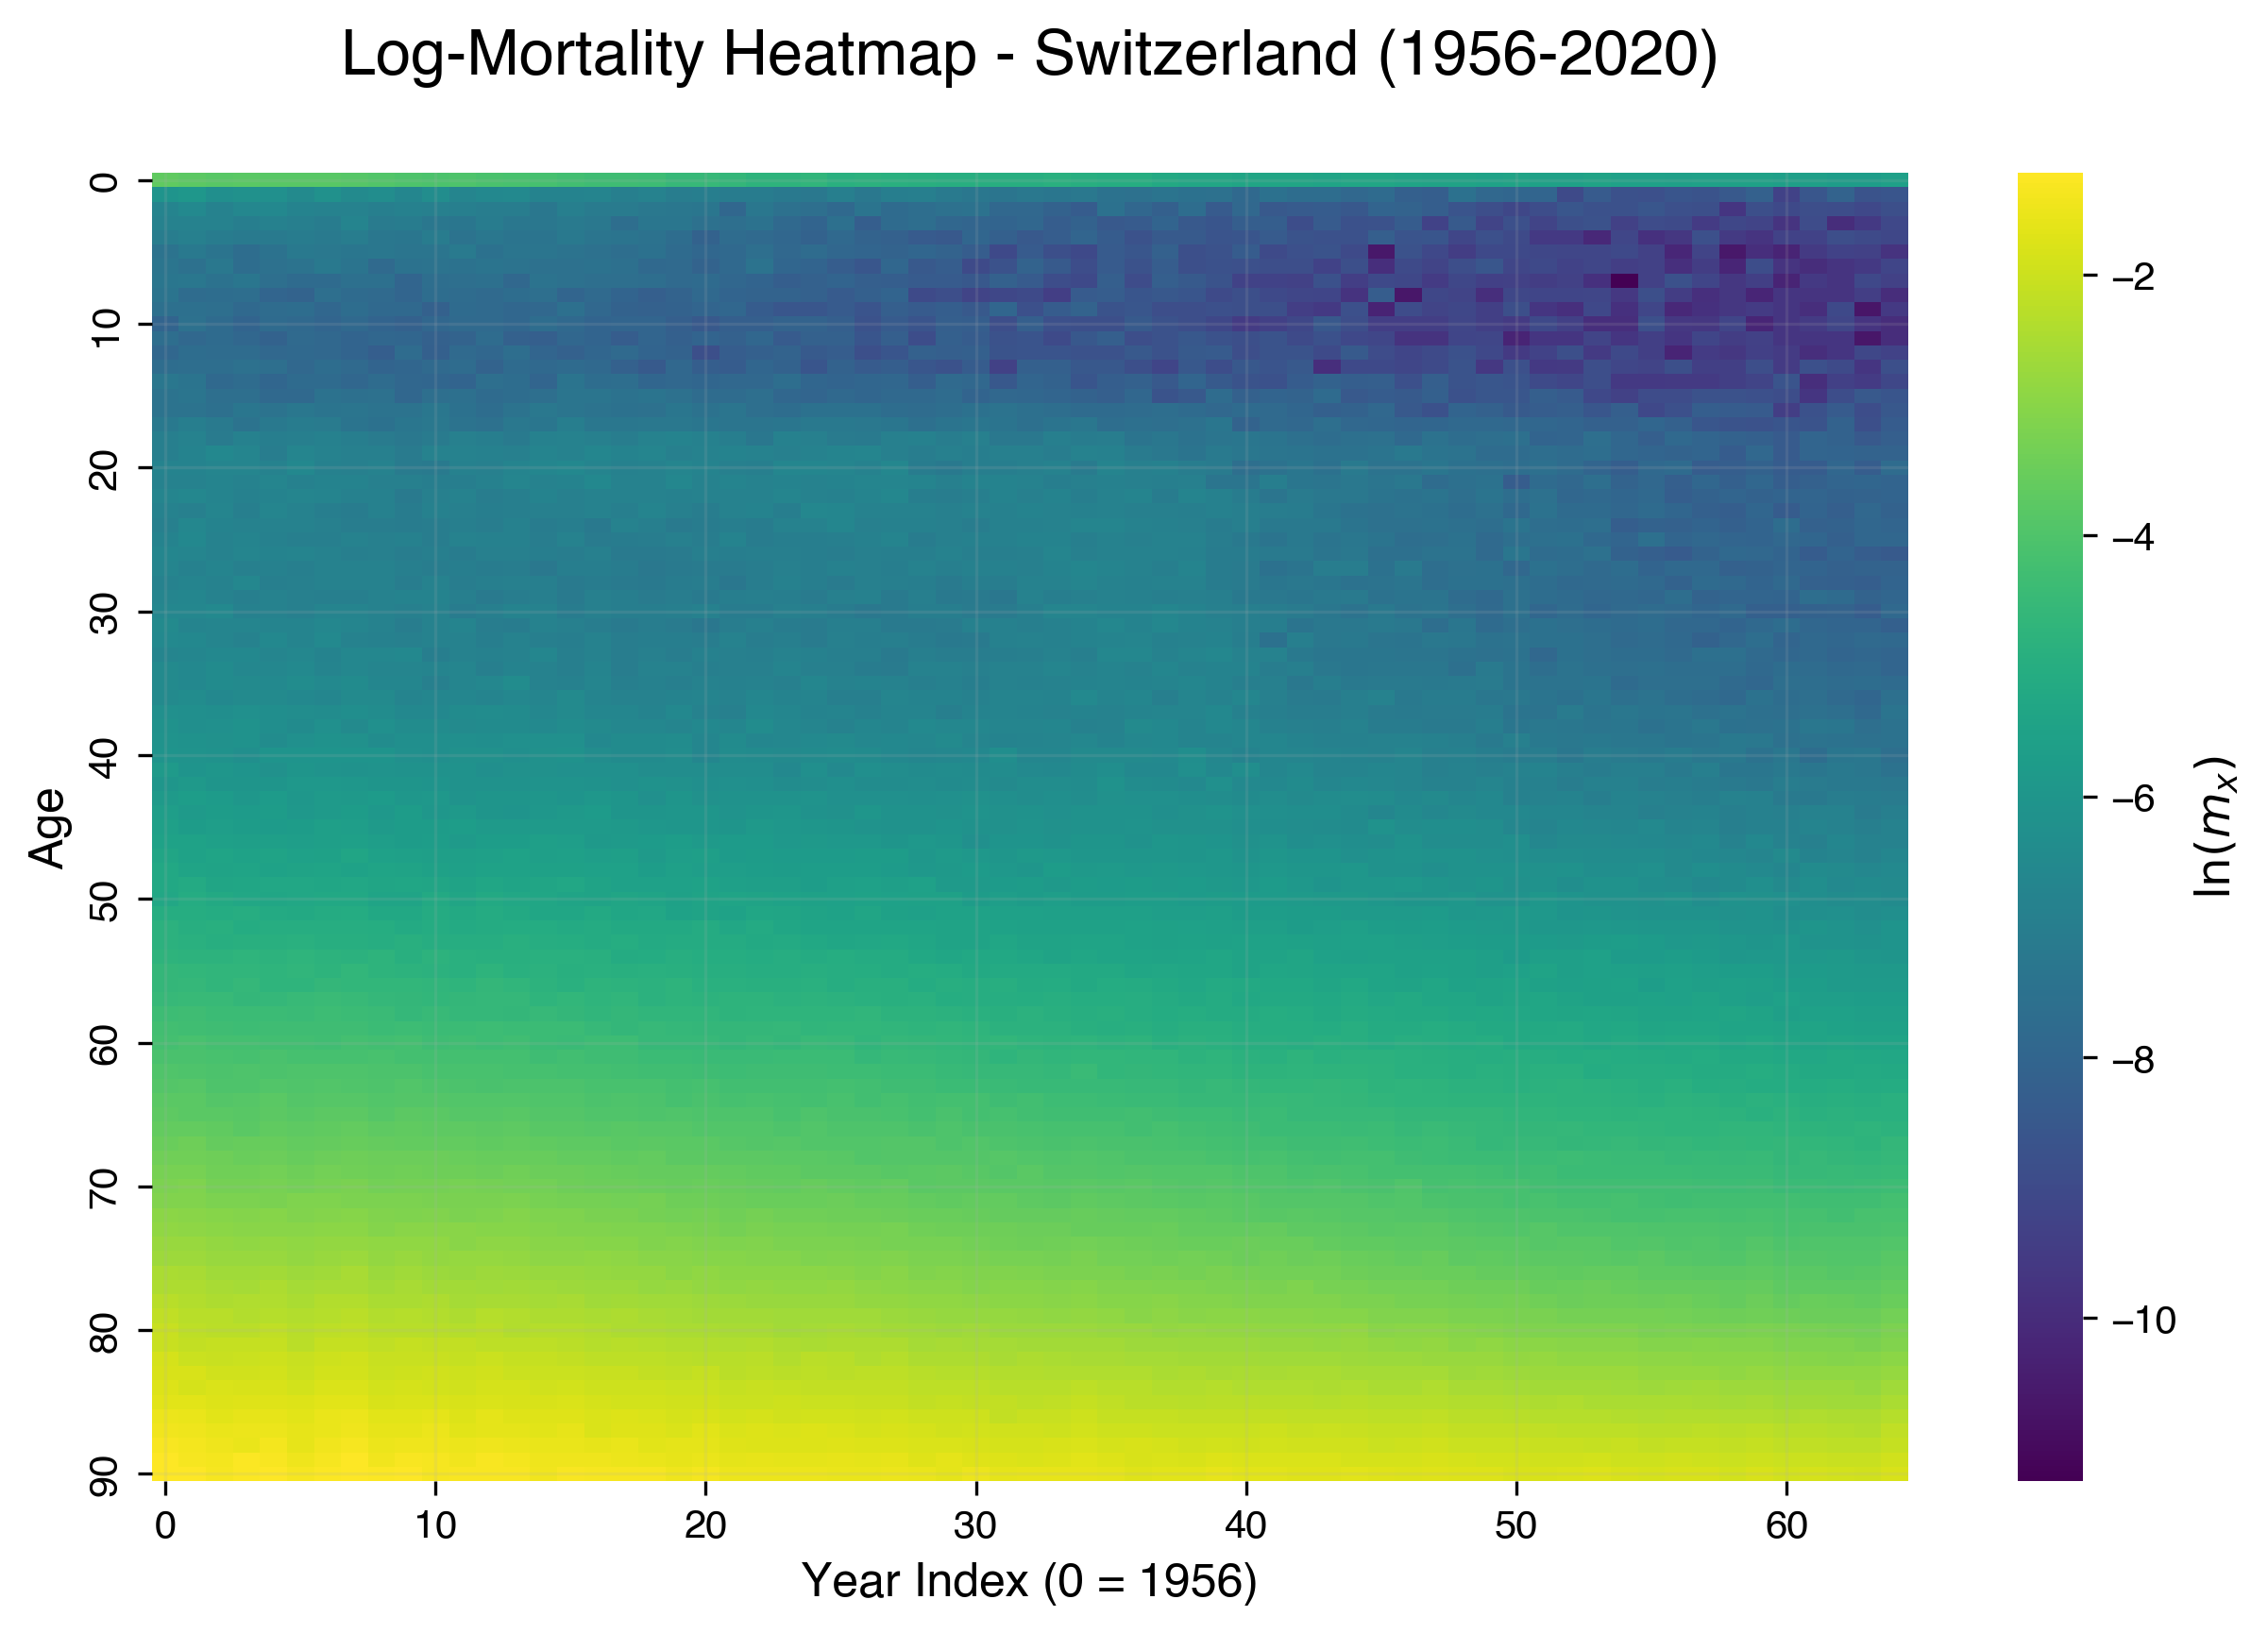

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress log(0) and runtime warnings for cleaner output
warnings.filterwarnings("ignore", category=RuntimeWarning) 

# 1. Identify the common time horizon dynamically
# We find the minimum end year available across all countries in the cluster
available_end_years = [df['Year'].max() for df in data_dict.values()]

START_YEAR = 1956
END_YEAR = min(available_end_years) 
AGES = np.arange(0, 91)
YEARS = np.arange(START_YEAR, END_YEAR + 1)

def get_mortality_matrix(df, start_year, end_year, ages):
    """
    Filters the dataframe and pivots it into an Age x Year matrix.
    Handles zero values by adding a tiny epsilon before log transformation.
    """
    subset = df[(df['Year'] >= start_year) & (df['Year'] <= end_year) & (df['Age'].isin(ages))]
    pivot_df = subset.pivot(index='Age', columns='Year', values='Total')
    
    # Fill zeros or NaNs with a very small value to allow stable log transformation
    epsilon = 1e-10
    mx_values = pivot_df.values.copy()
    mx_values[mx_values <= 0] = epsilon
    
    return np.log(mx_values)

# Dictionary to store aligned matrices (Age x Year)
mx_matrices = {}

print(f"Aligning cluster to common window: {START_YEAR}-{END_YEAR} (Width: {len(YEARS)} years)")

for code, df in data_dict.items():
    matrix = get_mortality_matrix(df, START_YEAR, END_YEAR, AGES)
    mx_matrices[code] = matrix
    print(f"Matrix created for {code}: {matrix.shape}")

# --- Verification Plot: Heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(mx_matrices['CHE'], xticklabels=10, yticklabels=10, 
            cmap='viridis', cbar_kws={'label': r'$\ln(m_x)$'})

ax.set_title(f"Log-Mortality Heatmap - Switzerland ({START_YEAR}-{END_YEAR})", pad=25)
ax.set_xlabel(f"Year Index (0 = {START_YEAR})")
ax.set_ylabel("Age")

# Save the professional figure
save_path = f"{FIGURES_DIR}fig02_heatmap_verification_CHE.png"
plt.savefig(save_path)
plt.show()

## 2.3. Individual Lee-Carter Estimation

Estimating Lee-Carter parameters for the period 1956-2020...
LC Parameters computed for CHE
LC Parameters computed for SWE
LC Parameters computed for NOR
LC Parameters computed for DEUTW
LC Parameters computed for NLD
LC Parameters computed for JPN


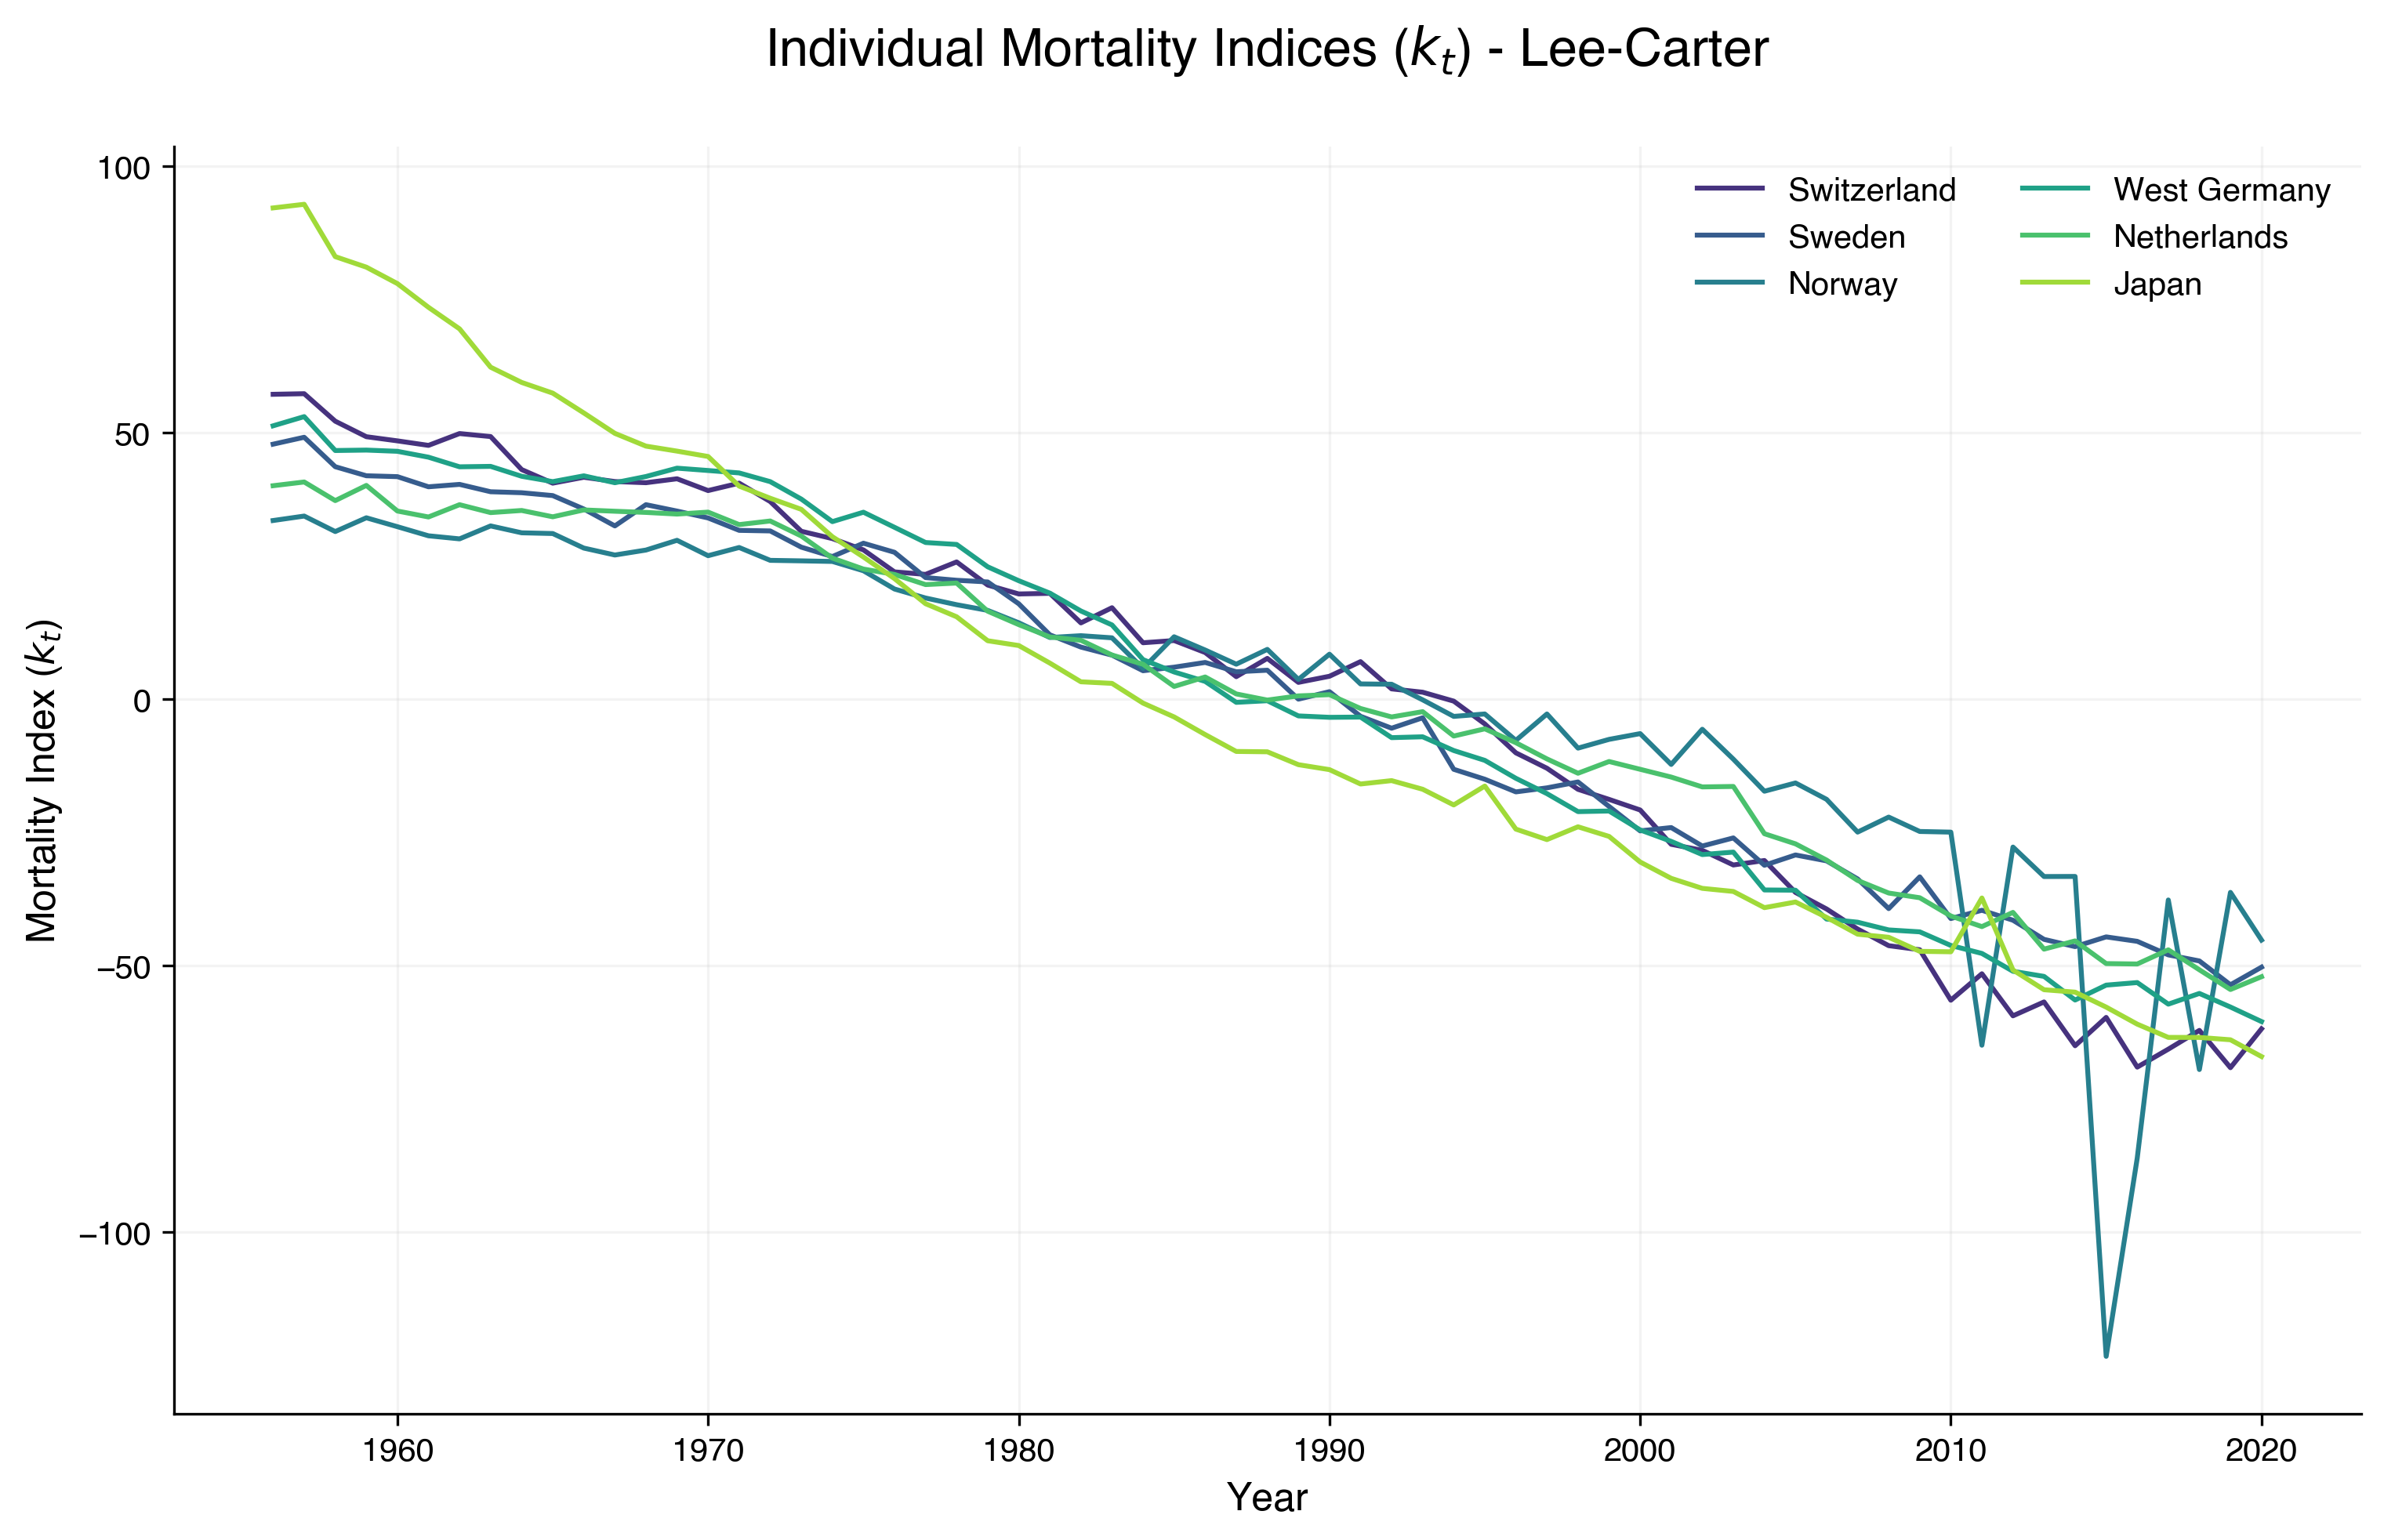

In [13]:
from scipy.linalg import svd

# Dictionaries to store LC parameters for each country
lc_params = {}

print(f"Estimating Lee-Carter parameters for the period {START_YEAR}-{END_YEAR}...")

for code, M in mx_matrices.items():
    # 1. Calculate ax: Average log-mortality over time for each age
    ax = np.mean(M, axis=1)
    
    # 2. Center the matrix by subtracting ax
    Z = M - ax[:, np.newaxis]
    
    # 3. Apply SVD to the centered matrix Z
    # We take the first component (rank-1 approximation)
    U, S, Vt = svd(Z, full_matrices=False)
    
    # 4. Extract bx (Age sensitivity) and kt (Time trend)
    # Convention: sum(bx) = 1 and sum(kt) = 0 (ensured by centering)
    bx_raw = U[:, 0]
    kt_raw = Vt[0, :] * S[0]
    
    # Normalize bx so it sums to 1 (Standard Actuarial Constraint)
    bx = bx_raw / np.sum(bx_raw)
    kt = kt_raw * np.sum(bx_raw)
    
    lc_params[code] = {
        'ax': ax,
        'bx': bx,
        'kt': kt
    }
    print(f"LC Parameters computed for {code}")

# --- Visualization: Individual kt trends (The Mortality Index) ---
fig, ax = plt.subplots()

for code, params in lc_params.items():
    ax.plot(YEARS, params['kt'], label=COUNTRIES[code], linewidth=1.5)

ax.set_title("Individual Mortality Indices ($k_t$) - Lee-Carter", pad=25)
ax.set_xlabel("Year")
ax.set_ylabel("Mortality Index ($k_t$)")
ax.legend(frameon=False, loc='upper right', ncol=2)

save_path = f"{FIGURES_DIR}fig03_lc_kt_comparison.png"
plt.savefig(save_path)
plt.show()

## 2.4. Li-Lee Common Factor Extraction ($B_x$ and $K_t$)

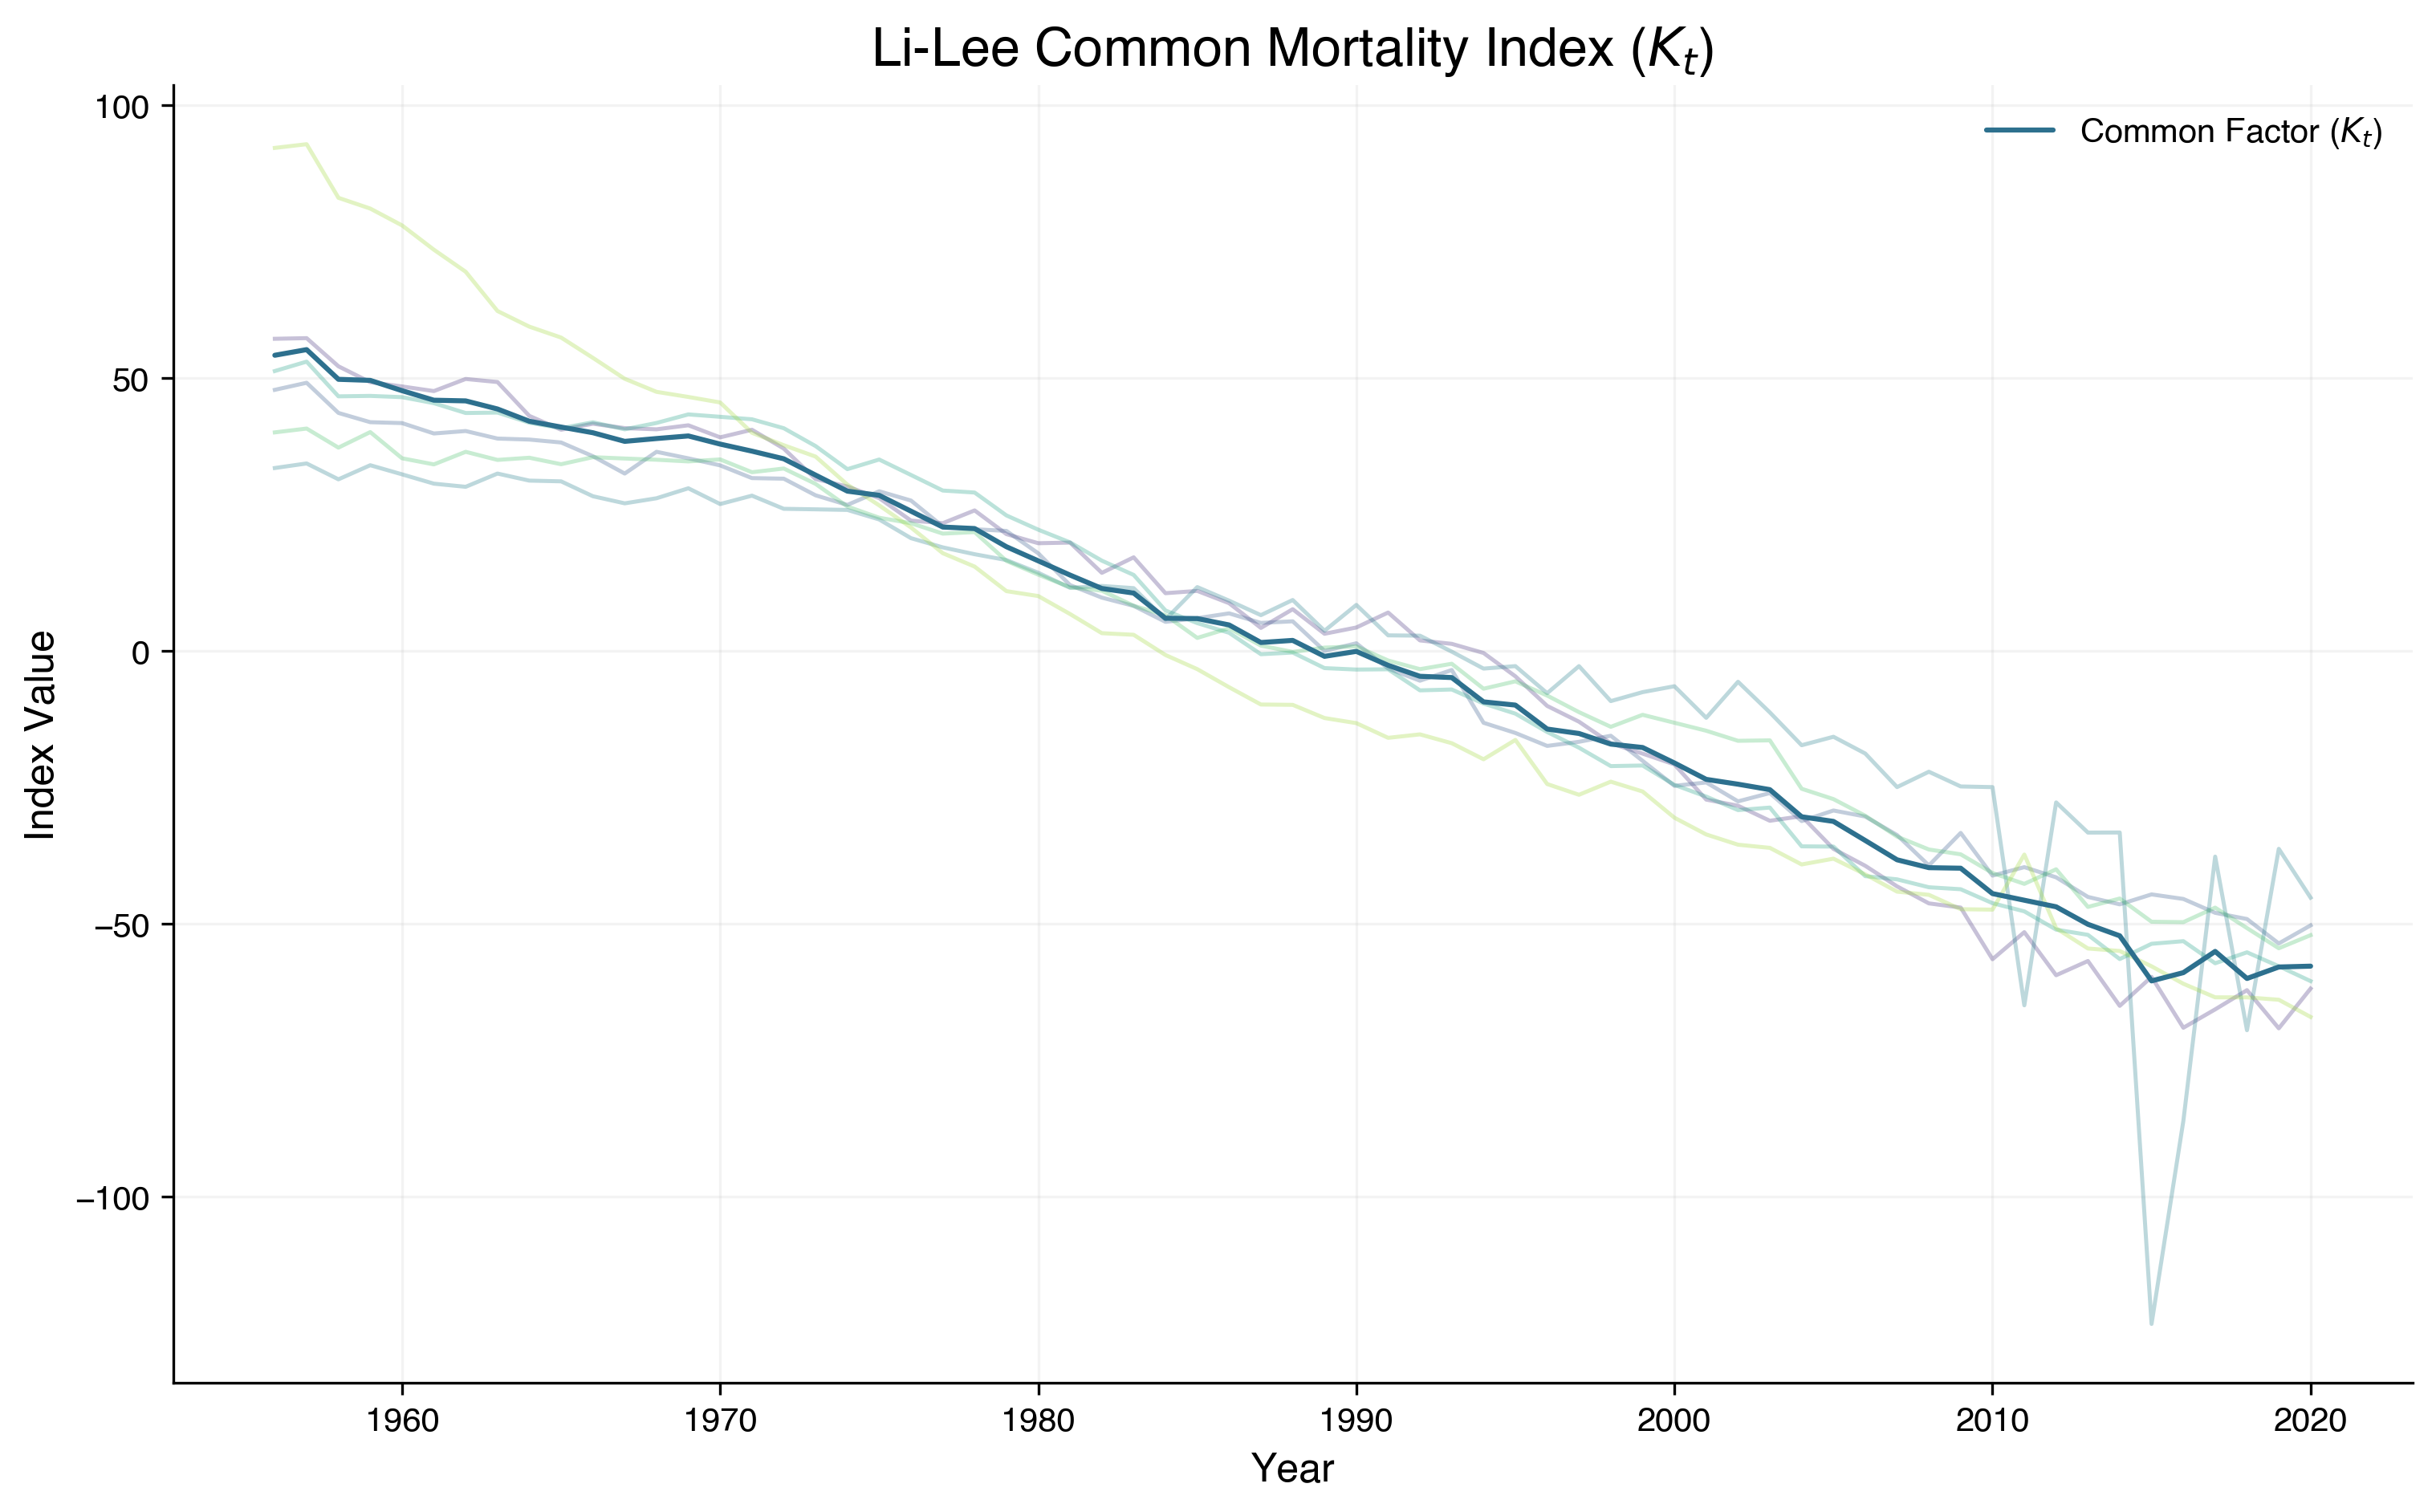

In [27]:
# 1. Reuse logic to extract common factors
all_matrices = np.array(list(mx_matrices.values()))
average_matrix = np.mean(all_matrices, axis=0) 

Ax_common = np.mean(average_matrix, axis=1)
Z_common = average_matrix - Ax_common[:, np.newaxis]
U_c, S_c, Vt_c = svd(Z_common, full_matrices=False)

Bx_common = U_c[:, 0] / np.sum(U_c[:, 0])
Kt_common = (Vt_c[0, :] * S_c[0]) * np.sum(U_c[:, 0])

# 2. Advanced Visuals
fig, ax = plt.subplots()

# Use the Viridis palette colors for the individual lines
# We make them thinner and slightly transparent (alpha)
colors = sns.color_palette("viridis", len(COUNTRIES))

for i, (code, params) in enumerate(lc_params.items()):
    ax.plot(YEARS, params['kt'], 
            color=colors[i], 
            alpha=0.3, 
            linewidth=1.2, 
            label='_nolegend_')

# For the Common Factor, we use a distinct, elegant color 
# 'DarkSlateGray' or the last color of Viridis
ax.plot(YEARS, Kt_common, 
        color='#2D708EFF',
        linewidth=1.5, 
        label='Common Factor ($K_t$)',
        solid_capstyle='round')

# Titles and Labels
ax.set_title("Li-Lee Common Mortality Index ($K_t$)")
ax.set_xlabel("Year")
ax.set_ylabel("Index Value")
ax.legend(frameon=False, loc='upper right')

# Save with the requested filename numbering
save_path = f"{FIGURES_DIR}fig04_li_lee_common_kt.png"
plt.savefig(save_path)
plt.show()